In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy

import shap

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv("anti_total.csv", index_col=False)

In [3]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data['ROOMNO'] = data['ROOMNO'].map(roomno_mapping)          

data['SEX'] = data['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data[col] = data[col].map({'Y': 1, 'N': 0})

In [4]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 500].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
dtype: float64

In [8]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols]
y = data_filter[final_cols]

In [9]:
X.shape, y.shape

((27968, 68), (27968, 19))

In [10]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])

In [11]:
X.columns

Index(['FEVER', 'VITALSIGNSGCS', 'CANCER', 'CRP', 'APTT', 'Neutrophil Seg.',
       'OTHERINFECTIONSITE_flag', 'LIVER', 'VITALSIGNSBT', 'CHECKITEM29SCORE',
       'PLT', 'VITALSIGNSRR', 'Bacteria level', 'CHECKITEM30SCORE', 'PT',
       'GPT', 'INFECTIONSITE2', 'Absolute Neutrophil count', 'DM',
       'Nitrite level', 'PH', 'WBC', 'Microscopic WBC level', 'StayTime_hours',
       'CHECKITEM28A', 'K', 'INFECTIONSITE3', 'HST', 'RESPIRATORY',
       'Microscopic RBC level', 'Hb', 'INFECTIONSITE4', 'Leukocyte level',
       'INR', 'SEX', 'INJURELEVEL', 'CHECKITEM31SCORE', 'CNS', 'Na',
       'INFECTIONSITE9', 'PCO2', 'CHECKITEM28SCORE', 'CARDIOVASCULAR',
       'KIDNEY', 'VITALSIGNSSPO2', 'O2 SAT', 'VITALSIGNSDBP', 'MAP',
       'Lymphocyte', 'INFECTIONSITE5', 'BE(ecf)', 'VITALSIGNSPR',
       'CHECKITEM32SCORE', 'HCO3', 'CHECKITEM27SCORE', 'AGE', 'T.Bilirubin',
       'INFECTIONSITE1', 'Ht', 'CHECKITEM27', 'Creatinine', 'AUTOIMMUNE'],
      dtype='object')

In [12]:
####################### Missing 70~80% #######################

# 檢驗

X['Leukocyte level_flag'] = (
     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

X['Nitrite level_flag'] = (
     X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

X['Bacteria level_flag'] = (
     X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic RBC level_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

X['Microscopic WBC level_flag'] = (
     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

X['PH_flag'] = (
     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# 計分

X['CHECKITEM29SCORE_flag'] = (
     X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM30SCORE_flag'] = (
     X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


####################### Missing > 80% #######################

# 檢驗

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['T.Bilirubin_flag'] = (
     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

X['PT_flag'] = (
     X['PT'].fillna('').str.strip().ne('').astype(int))

X['HST_flag'] = (
     X['HST'].fillna('').str.strip().ne('').astype(int))

X['INR_flag'] = (
     X['INR'].fillna('').str.strip().ne('').astype(int))

X['APTT_flag'] = (
     X['APTT'].fillna('').str.strip().ne('').astype(int))

X['PCO2_flag'] = (
     X['PCO2'].fillna('').str.strip().ne('').astype(int))

X['HCO3_flag'] = (
     X['HCO3'].fillna('').str.strip().ne('').astype(int))


X['BE(ecf)_flag'] = (
     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

X['O2 SAT_flag'] = (
     X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# 計分

X['CHECKITEM28A_flag'] = (
     X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27_flag'] = (
     X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM27SCORE_flag'] = (
     X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM28SCORE_flag'] = (
     X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM31SCORE_flag'] = (
     X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

X['CHECKITEM32SCORE_flag'] = (
     X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


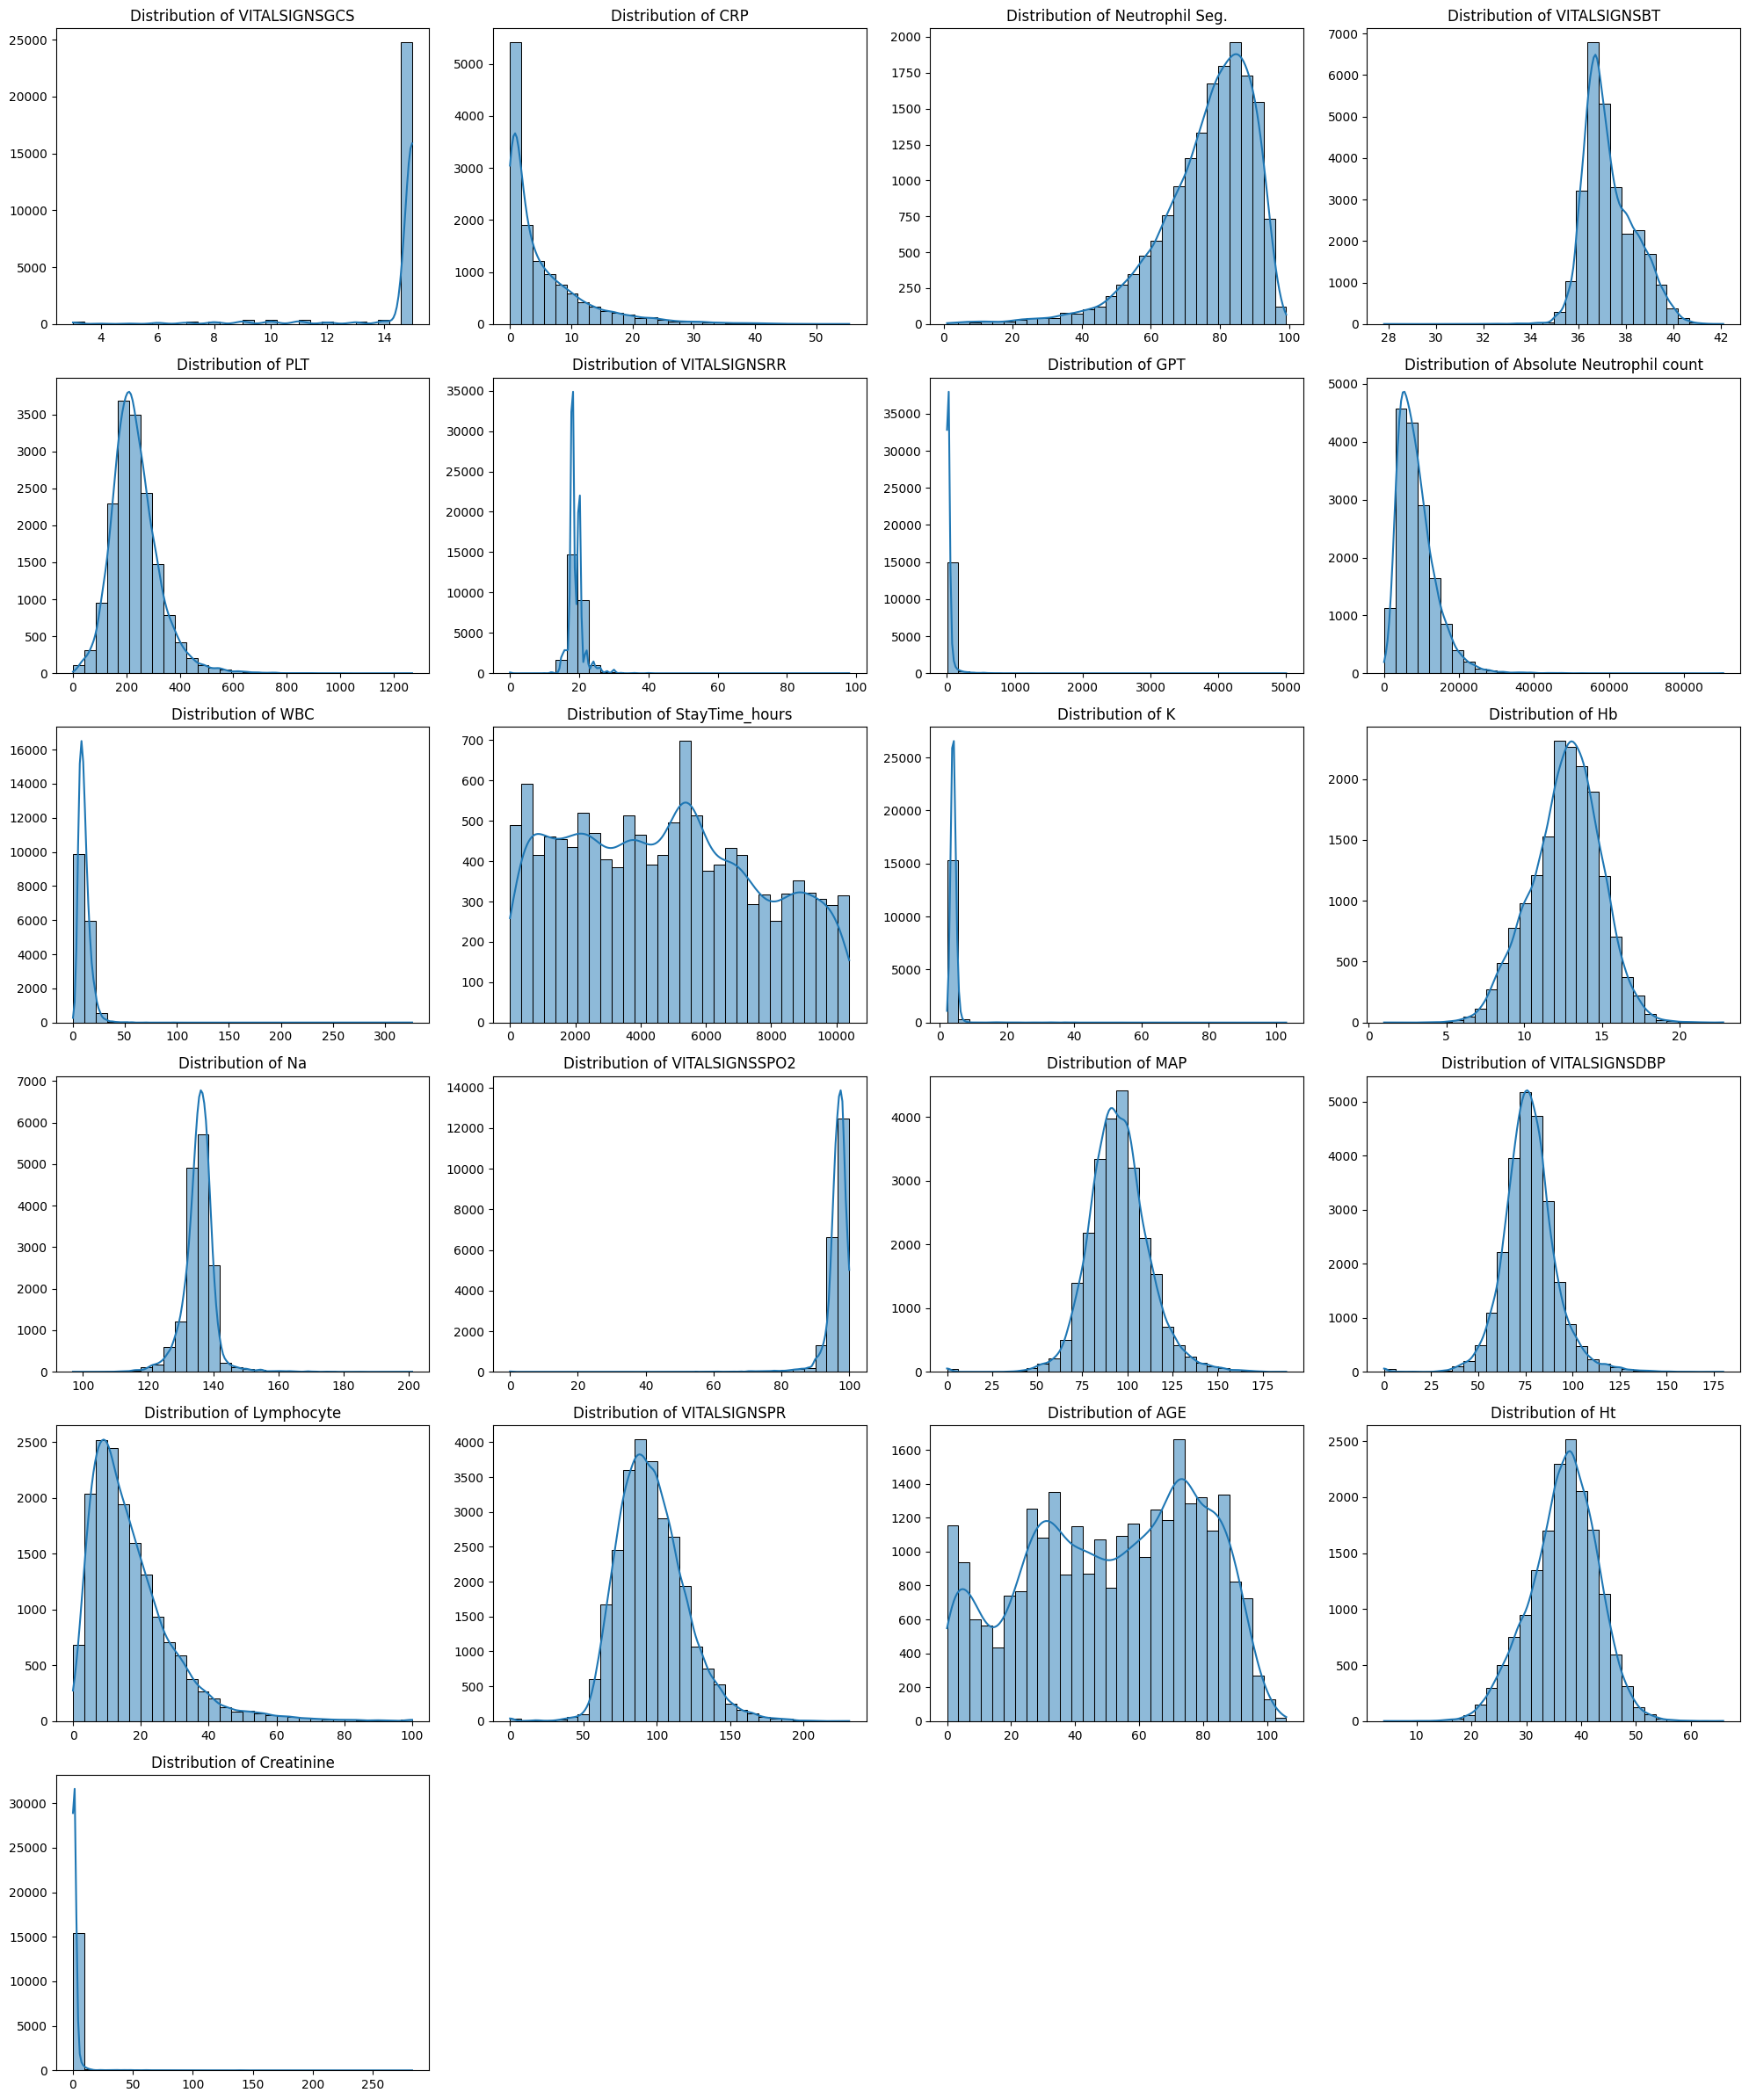

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [14]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 8350

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSBT                              260                   265   
VITALSIGNSPR                              239                   263   
VITALSIGNSDBP                             234                   236   
MAP                                       225                   237   
VITALSIGNSRR                              121                   234   
WBC                                       165                   165   
Ht                                        162                   166   
PLT                                       163                   165   
Absolute Neutrophil count                 162                   163   
Neutrophil Seg.                           162                   159   

                           Total_Outliers  
VITALSIGNSBT                          525  
VITALSIGNSPR                          502  
VITALSIGNSDBP                         470  
MAP  

In [15]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25171, 85), (25171, 19), (2797, 85), (2797, 19))

In [17]:
X_train.isnull().sum(), X_test.isnull().sum()

(FEVER                        0
 VITALSIGNSGCS              367
 CANCER                       0
 CRP                      13602
 APTT                     20358
                          ...  
 CHECKITEM27_flag             0
 CHECKITEM27SCORE_flag        0
 CHECKITEM28SCORE_flag        0
 CHECKITEM31SCORE_flag        0
 CHECKITEM32SCORE_flag        0
 Length: 85, dtype: int64,
 FEVER                       0
 VITALSIGNSGCS              41
 CANCER                      0
 CRP                      1514
 APTT                     2283
                          ... 
 CHECKITEM27_flag            0
 CHECKITEM27SCORE_flag       0
 CHECKITEM28SCORE_flag       0
 CHECKITEM31SCORE_flag       0
 CHECKITEM32SCORE_flag       0
 Length: 85, dtype: int64)

In [18]:
X_train.dtypes, X_test.dtypes

(FEVER                      int64
 VITALSIGNSGCS            float64
 CANCER                     int64
 CRP                      float64
 APTT                     float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 85, dtype: object,
 FEVER                      int64
 VITALSIGNSGCS            float64
 CANCER                     int64
 CRP                      float64
 APTT                     float64
                           ...   
 CHECKITEM27_flag           int32
 CHECKITEM27SCORE_flag      int32
 CHECKITEM28SCORE_flag      int32
 CHECKITEM31SCORE_flag      int32
 CHECKITEM32SCORE_flag      int32
 Length: 85, dtype: object)

In [19]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    4990.0
Flomoxef                       4650.0
Cefazolin                      2151.0
Cefixime                       1962.0
Ciprofloxacin                  1860.0
Azithromycin                   1843.0
Cefuroxime                     1541.0
Piperacillin/Tazobactam        1356.0
Cefoperazone/sulbactam         1278.0
Peramivir                      1013.0
Baloxavir marboxil              977.0
Metronidazole                   923.0
Cefadroxil                      816.0
Oseltamivir                     745.0
Levofloxacin                    650.0
Clindamycin                     560.0
Gentamicin                      556.0
Ceftriaxone                     551.0
Cephalexin                      465.0
dtype: float64

In [20]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

# num_cols = ['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
#             'Lymphocyte', 'CRP', 'Hb', 'Creatinine', 'Leukocyte', 'PCO2', 'INR', 'Absolute Neutrophil count', 'Ht', 'HST', 'BE(ecf)', 'T.Bilirubin',
#            'Na', 'K', 'GPT', 'O2 SAT', 'HCO3', 'PT', 'APTT', 'PLT']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [21]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [22]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [23]:
X_train['Lymphocyte']

336       9.5
14403     7.1
21349    14.2
25494     6.7
1731     14.2
         ... 
15377     3.3
21602     6.0
17730    37.6
15725     9.9
19966    14.6
Name: Lymphocyte, Length: 25171, dtype: float64

In [24]:
# fill score

score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
              'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
              'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
              'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
              'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [25]:
y_train.sum(axis=1).mean() # 每人平均用1.65個抗生素

1.1476302093679234

In [26]:
drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
             'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
             'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
             'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [27]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [28]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(25171, 62)

In [29]:
X_train.columns

Index(['FEVER', 'VITALSIGNSGCS', 'CANCER', 'CRP', 'Neutrophil Seg.',
       'OTHERINFECTIONSITE_flag', 'LIVER', 'VITALSIGNSBT', 'PLT',
       'VITALSIGNSRR', 'GPT', 'INFECTIONSITE2', 'Absolute Neutrophil count',
       'DM', 'WBC', 'StayTime_hours', 'K', 'INFECTIONSITE3', 'RESPIRATORY',
       'Hb', 'INFECTIONSITE4', 'SEX', 'INJURELEVEL', 'CNS', 'Na',
       'INFECTIONSITE9', 'CARDIOVASCULAR', 'KIDNEY', 'VITALSIGNSSPO2',
       'VITALSIGNSDBP', 'MAP', 'Lymphocyte', 'INFECTIONSITE5', 'VITALSIGNSPR',
       'AGE', 'INFECTIONSITE1', 'Ht', 'Creatinine', 'AUTOIMMUNE',
       'Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag',
       'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
       'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', 'HST_flag',
       'T.Bilirubin_flag', 'PT_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag',
       'HCO3_flag', 'BE(ecf)_flag', 'O2 SAT_flag', 'CHECKITEM28A_flag',
       'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKI

In [30]:
# LogisticRegressionCV?
# XGBClassifier?
# RandomForestClassifier?
# MultiOutputClassifier.fit?

Init signature:
LogisticRegressionCV(
    *,
    Cs=10,
    fit_intercept=True,
    cv=None,
    dual=False,
    penalty='l2',
    scoring=None,
    solver='lbfgs',
    tol=0.0001,
    max_iter=100,
    class_weight=None,
    n_jobs=None,
    verbose=0,
    refit=True,
    intercept_scaling=1.0,
    multi_class='deprecated',
    random_state=None,
    l1_ratios=None,
)
Docstring:     
Logistic Regression CV (aka logit, MaxEnt) classifier.

See glossary entry for :term:`cross-validation estimator`.

This class implements logistic regression using liblinear, newton-cg, sag
or lbfgs optimizer. The newton-cg, sag and lbfgs solvers support only L2
regularization with primal formulation. The liblinear solver supports both
L1 and L2 regularization, with a dual formulation only for the L2 penalty.
Elastic-Net penalty is only supported by the saga solver.

For the grid of `Cs` values and `l1_ratios` values, the best hyperparameter
is selected by the cross-validator
:class:`~sklearn.model_select

In [31]:
# label_freq = y_train.mean(axis=0)

# label_weight = 1 / (label_freq + 0.0000001)
# label_weight = label_weight / label_weight.mean()

# print(label_weight)

# sample_weight = np.ones(len(y_train))

# for i, col in enumerate(y_train.columns):
#     sample_weight += y_train[col] * label_weight[i]

# sample_weight = sample_weight / sample_weight.mean()


Amoxicillin/Clavulanic acid    0.196379
Azithromycin                   0.531703
Baloxavir marboxil             1.002997
Cefadroxil                     1.200892
Cefazolin                      0.455569
Cefixime                       0.499454
Cefoperazone/sulbactam         0.766767
Ceftriaxone                    1.778450
Cefuroxime                     0.635905
Cephalexin                     2.107366
Ciprofloxacin                  0.526844
Clindamycin                    1.749868
Flomoxef                       0.210738
Gentamicin                     1.762457
Levofloxacin                   1.507580
Metronidazole                  1.061677
Oseltamivir                    1.315339
Peramivir                      0.967353
Piperacillin/Tazobactam        0.722661
dtype: float64


C:\Users\482525\AppData\Local\Temp\ipykernel_16660\1365444744.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sample_weight += y_train[col] * label_weight[i]


In [32]:
# base_model = LogisticRegressionCV (penalty='l1',
#                                    cv=3,
#                                    class_weight='balanced',
#                                    solver='liblinear',
#                                    max_iter=1000,
#                                    random_state=123)

base_model = RandomForestClassifier(
                                    n_estimators=800, 
                                    class_weight='balanced',
                                    min_samples_leaf=5,
                                    min_samples_split=10,
                                    max_depth=15,
                                    n_jobs=-1,
                                    random_state=123)

# base_model = XGBClassifier(n_estimators=300,
#                            max_depth=5,
#                            learning_rate=0.05,
#                            subsample=0.8,
#                            colsample_bytree=0.8,
#                            eval_metric='logloss',
#                            gamma=0,
#                            reg_alpha=1,
#                            reg_lambda=0,
#                            min_child_weight=1,
#                            random_state =123,
#                            n_jobs=-1
#     )

multi_model = MultiOutputClassifier(base_model)
# multi_model = ClassifierChain(base_model, order='random', random_state =123)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

,estimator,RandomForestC...dom_state=123)
,n_jobs,None
,n_estimators,800
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [33]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.5783256511951977
0.5946013646418735


In [34]:
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])

threshold = 0.5
y_pred = (y_prob_list > threshold).astype(int)

# y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

In [35]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.4334249313015239
0.3435979454146607


In [36]:
hamming_loss(y_test, y_pred)

0.08535460926180306

In [37]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.35750804433321415

In [38]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    APs = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        score = 0
        hits = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)
        APs.append(score / min(len(actual), k))
    return np.mean(APs)

In [39]:
hit3 = hit_rate_at_k(y_test.values, y_prob_list, k=3)
print('Hit@3: ', hit3)

Hit@3:  0.6953879156238827


In [40]:
precision3 = precision_at_k(y_test.values, y_prob_list, k=3)
print('precision@3: ', precision3)

precision@3:  0.25789536408056557


In [41]:
recall_3 = recall_at_k(y_test.values, y_prob_list, k=3)
print('Recall@3: ', recall_3)

Recall@3:  0.6951880178457616


In [42]:
map_3 = map_at_k(y_test.values, y_prob_list, k=3)
print('MAP@3: ', map_3)

MAP@3:  0.34287231782451666


In [43]:
target_names = y_train.columns

for i, col in enumerate(target_names):
    print(f'-- {col} --')
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))

-- Amoxicillin/Clavulanic acid --
              precision    recall  f1-score   support

         0.0       0.93      0.71      0.81      2272
         1.0       0.38      0.78      0.52       525

    accuracy                           0.72      2797
   macro avg       0.66      0.75      0.66      2797
weighted avg       0.83      0.72      0.75      2797

-- Azithromycin --
              precision    recall  f1-score   support

         0.0       0.95      0.87      0.91      2587
         1.0       0.21      0.44      0.29       210

    accuracy                           0.84      2797
   macro avg       0.58      0.65      0.60      2797
weighted avg       0.89      0.84      0.86      2797

-- Baloxavir marboxil --
              precision    recall  f1-score   support

         0.0       0.99      0.92      0.95      2689
         1.0       0.26      0.70      0.38       108

    accuracy                           0.91      2797
   macro avg       0.62      0.81      0.67      2

C:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [44]:
importance_all = []

for i, drug in enumerate(y_train.columns):
    
    model = multi_model.estimators_[i]
    
    # 建立 Series 並與特徵名稱對應
    imp = pd.Series(
        model.feature_importances_,
        index=X_train.columns
    )

    imp_df = imp.reset_index()
    imp_df.columns = ['feature','importance']
    imp_df['drug'] = drug
    
    imp_df_sorted = imp_df.sort_values("importance", ascending=False)
    
    print(f"=== Drug: {drug} (Top 10 Features) ===")
    print(imp_df_sorted.head(20).to_string(index=False)) # 不印索引比較美觀
    print('\n')
    print(f"Top 20 importance sum: {imp_df_sorted.head(20)['importance'].sum().round(3)}")
    print("-" * 40)
    
    importance_all.append(imp_df_sorted)

importance_all = pd.concat(importance_all)

=== Drug: Amoxicillin/Clavulanic acid (Top 10 Features) ===
                   feature  importance                        drug
            INFECTIONSITE2    0.088018 Amoxicillin/Clavulanic acid
            INFECTIONSITE5    0.067155 Amoxicillin/Clavulanic acid
                       AGE    0.052830 Amoxicillin/Clavulanic acid
            INFECTIONSITE3    0.032685 Amoxicillin/Clavulanic acid
                 APTT_flag    0.029553 Amoxicillin/Clavulanic acid
          T.Bilirubin_flag    0.028033 Amoxicillin/Clavulanic acid
                   PT_flag    0.027800 Amoxicillin/Clavulanic acid
              VITALSIGNSBT    0.026997 Amoxicillin/Clavulanic acid
                  INR_flag    0.026859 Amoxicillin/Clavulanic acid
              VITALSIGNSPR    0.026138 Amoxicillin/Clavulanic acid
                Creatinine    0.025610 Amoxicillin/Clavulanic acid
      Leukocyte level_flag    0.024347 Amoxicillin/Clavulanic acid
                       CRP    0.023526 Amoxicillin/Clavulanic acid
  

In [45]:
importance_summary = importance_all.groupby('feature')['importance'].mean().sort_values(ascending=False)

print(importance_summary.head(20))

feature
AGE                          0.072971
INFECTIONSITE2               0.062856
VITALSIGNSBT                 0.058061
INFECTIONSITE1               0.044292
CRP                          0.040995
VITALSIGNSPR                 0.035512
WBC                          0.034980
Absolute Neutrophil count    0.031540
MAP                          0.027558
Lymphocyte                   0.027066
Neutrophil Seg.              0.025925
VITALSIGNSDBP                0.025323
Creatinine                   0.025318
Ht                           0.025281
Hb                           0.022811
PLT                          0.022747
StayTime_hours               0.022637
APTT_flag                    0.021010
INFECTIONSITE5               0.020785
FEVER                        0.020544
Name: importance, dtype: float64


In [46]:
importance_summary = importance_all.groupby('feature')['importance'].median().sort_values(ascending=False)

print(importance_summary.head(20))

feature
AGE                          0.070732
CRP                          0.043585
INFECTIONSITE1               0.037391
VITALSIGNSBT                 0.037080
VITALSIGNSPR                 0.036928
INFECTIONSITE2               0.035095
Absolute Neutrophil count    0.031971
WBC                          0.030492
Lymphocyte                   0.028295
MAP                          0.027177
Creatinine                   0.024394
Neutrophil Seg.              0.024278
PLT                          0.024222
Ht                           0.023440
VITALSIGNSDBP                0.023225
StayTime_hours               0.022265
Hb                           0.020137
GPT                          0.018734
VITALSIGNSSPO2               0.016407
Na                           0.016353
Name: importance, dtype: float64


In [47]:
# explainer = shap.Explainer(multi_model, X_train[:1000])  
# shap_values = explainer(X_test[:100])  

# np.random.seed(123) 

# shap.summary_plot(shap_values, X_test[:10])


# # shap.dependence_plot("GrLivArea", shap_values.values, X_test[:10]) 


# shap.plots.waterfall(shap_values[0]) 

# shap.plots.beeswarm(shap_values)